# **30 · P5 평가 — 결론은 한 칸이 아니라 사다리 전체가 떠받친다**

### **"증거 사다리 ①~⑤ 전 칸 통과 · 세 잣대(정렬 잠재·단일문항·합성)의 종점 방향 일치 · APC 기간효과 동행 r=+0.99/+0.96 — 그럼에도 '유의한 추세'라고는 말하지 않는다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 종합 대상 = **P2~P4 전 산출**(20 EDA → 21 MGCFA → 22 semopy → 23 정렬 → 24 MK+APC) · 방법 = **증거 사다리 + 삼각검증** (새 추정 없음)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(종합 평가)** · CRISP-DM **P5(Evaluation)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 어떤 기준을 통과해야 "추세가 보인다"를 **"검증된 결과"로 승격**할 수 있는가 — 그리고 본 분석은 그 기준을 통과했는가?
> **Q2.** 구성개념·척도·추정방법이 서로 다른 세 궤적과 APC 기간효과는 **어디서 일치하고 어디서 어긋나는가** — 어긋남(정직한 불일치)을 어떻게 처리하는가?
> **Q3.** 사다리를 전부 통과한 뒤에도 **무엇을 아직 단정하지 않는가** — 검증 게이트와 결론의 자격등급.

## **이 노트북의 위상 — 새 분석을 만들지 않는다**

23이 "추세를 **만들지 않고** 비교 자격을 판정"했고(정렬법), 24가 "추세의 통계적 성격(MK)과 정체(APC)를 분해"했다면, 30은 **아무것도 새로 추정하지 않는다**. P2~P4가 이미 산출해 출처 문서에 박제한 수치를 **인용 상수**로 불러와 하나의 평가 서사로 종합하는 **메타 평가**다. 따라서 이 노트북의 핵심 검증 포인트는 계산 재현이 아니라 — **"인용 상수가 출처 문서 수치에서 한 자리도 어긋나지 않았는가"(상수 drift 없음, §6)** 이다.

- **로직 SSOT(thin import)**: [`src/p5_evaluation.py`](../src/p5_evaluation.py) — 인용 상수 5종(`ALIGN_ALPHA`·`TRUST_SINGLE`·`CRED_MEAN`·`PERIOD_HAPC`·`PERIOD_IE`) + 사다리 `LADDER` + 도식 2종. 재구현 금지.
- **출처 문서(SSOT)**: [`docs/design/p5-evaluation.md`](../docs/design/p5-evaluation.md) — 본 노트북의 §번호는 이 문서의 §0~§7과 대응.
- ✅ **검증 게이트 해소**(`data-spec.md` §6 → [kpf-revalidation](../docs/design/kpf-revalidation.md), 2026-07-11 · 노트북 `12`): 신뢰 절대수준·배터리가 공식 보고서와 **전 셀 일치** — 인용 자격등급은 p6-pdf-structure §3 표를 따른다(잠재척도 크기는 여전히 '방향만').

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 평가 기준 — 4개 관문(C1~C4) + **Decision Box ①** | 판정표 |
| 2 | [발견] 증거 사다리 — ①~⑤ 전 칸 통과 + [시각화] | 사다리 표·figure |
| 3 | [발견] 삼각검증 — 일치와 정직한 불일치 + **Decision Box ②** + [시각화] | 궤적 표·figure |
| 4 | 강건성 종합 — 여섯 축 흔들기 + 민감점 4건 | 종합표 |
| 5 | 한계·검증 게이트 — 결론 자격등급 + **Decision Box ③** | 등급표 |
| 6 | 검증 셀 — 인용 상수 ↔ SSOT 문서 drift 없음 | assert PASS |
| 7 | 종합 — 연구질문 답·단계요약·B트랙 완결·다음 | — |
| 8 | `src/p5_evaluation.py` 코드리뷰 결론 | — |


In [1]:
import sys, re
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "p5_evaluation.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import p5_evaluation as P            # SSOT — 인용 상수·사다리·도식(재구현 금지)
from IPython.display import Image, display

used = P.setup_korean_font()
print(f"한글 폰트: {used}")
print(f"인용 상수 로드 — ALIGN_ALPHA {len(P.ALIGN_ALPHA)}개년 · TRUST_SINGLE {len(P.TRUST_SINGLE)}개년 · "
      f"CRED_MEAN {len(P.CRED_MEAN)}개년 · PERIOD_HAPC/IE {len(P.PERIOD_HAPC)}/{len(P.PERIOD_IE)}개년")
print(f"증거 사다리 단계 수 = {len(P.LADDER)} (①~⑤)")

DOCS = ROOT / "docs" / "design"
SRC_DOCS = ["p5-evaluation.md", "alignment-trust-trend.md", "trend-apc-results.md",
            "eda-overview.md", "mgcfa-invariance-results.md", "mgcfa-semopy-crossval.md"]
assert all((DOCS / d).exists() for d in SRC_DOCS), "출처 문서 누락"
print("출처 문서 6종 확인:", ", ".join(SRC_DOCS))

한글 폰트: Malgun Gothic
인용 상수 로드 — ALIGN_ALPHA 7개년 · TRUST_SINGLE 6개년 · CRED_MEAN 7개년 · PERIOD_HAPC/IE 7/7개년
증거 사다리 단계 수 = 5 (①~⑤)
출처 문서 6종 확인: p5-evaluation.md, alignment-trust-trend.md, trend-apc-results.md, eda-overview.md, mgcfa-invariance-results.md, mgcfa-semopy-crossval.md


## **1. [전제] 평가의 질문 — "보이는 추세"를 "결론"으로 승격해도 되는가**

P5는 새로운 질문("추세가 있는가")을 던지지 않는다. 이미 보인 신호(23의 Δα=+0.671, 24의 기간효과)를 **결론으로 승격해도 되는가**를 판정한다. 판정은 4개 관문의 직렬 통과로 한다 — 하나라도 실패하면 해당 신호는 §5 한계로 강등된다.

| 관문 | 질문 | 통계적 의미 | 충족 조건 | 판정 | 출처 |
|------|------|------------|-----------|:---:|------|
| **C1 측정 동등** | 연도 간 **같은 잣대**로 측정했나? | 비교가능성(comparability) — 잠재평균 비교의 *자격* | MGCFA metric 동등 + 정렬 비동등 ≤20% | ✅ | invariance §1 / alignment §1 |
| **C2 추정 재현성** | 추정이 특정 **라이브러리의 산물**은 아닌가? | 엔진 독립성 — 구현 오류·수치 특이성 배제 | 직접구현 ↔ 독립 SEM 라이브러리 일치 | ✅ | semopy §1·§2 |
| **C3 삼각 일관성** | 서로 다른 지표·방법이 **같은 이야기**를 하나? | 수렴 증거(convergent evidence) — 방법 선택의 인공물 배제 | 정렬·단일문항·합성 + APC 방향 일치 | ✅ | 본 §3 |
| **C4 강건성** | 가중·표본·지표·기준을 **바꿔도 유지**되나? | 연구자 자유도(researcher degrees of freedom) 통제 | robustness 변형 전부 같은 방향 | ✅ | 본 §4 |

이 4관문은 대회 정성평가의 **분석타당성·실현가능성**과 직결된다(`analysis-master-plan.md` §2) — "단일연도 EDA"가 아니라 **측정학적으로 자격을 검증한 추세**라는 점이 본 파이프라인의 차별점이다.

### **Decision Box ① — '검증된 결과'의 인정 기준: 왜 4관문 전부인가**

**기준: 무엇이 충족되면 추세 수치를 '검증된 결과'로 승격하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 유의성 단일 기준 | MK p<.05면 인정 | ❌ n=7 저검정력에서 p는 정보가 거의 없고(24 DB③: 점추정 p=0.381), 설령 유의해도 측정 비동등이면 "서로 다른 잣대의 비교"가 유의했을 뿐 — **자격 문제를 건드리지 못함** |
| (b) 적합도 단일 기준 | CFA CFI 좋으면 인정 | ❌ 적합은 모형-데이터 정합일 뿐 — 라이브러리 의존(C2)·삼각 불일치(C3)·가중 민감성(C4)을 하나도 걸러내지 못함 |
| (c) **4관문 직렬(C1→C4)** | 자격 → 엔진 → 수렴 → 강건 전부 통과 | ✅ **채택** — 하나라도 실패하면 승격 보류(§5 강등). 관문이 *직렬*인 이유는 §2 사다리와 동형: 아래가 무너지면 위의 통과는 의미를 잃는다 |

**이 선의 효과**: "추세 있음"이라는 주장의 근거가 p값 하나가 아니라 **측정학적 자격(C1) + 독립 재현(C2) + 수렴(C3) + 강건성(C4)의 합**이 된다 — 어느 한 관문의 반례가 나오면 결론이 어디서 부러지는지 즉시 특정할 수 있다.

## **2. [발견] 증거 사다리 — 다섯 칸 전부 '통과', 결론이 사다리 전체의 무게를 견딘다**

추세 결론은 단일 분석이 아니라 **하위 단계가 상위 단계의 전제를 보증하는 사다리**로 성립한다:

- **①이 무너지면**(핵심3지표가 단일차원이 아니면) → CFA에 넣을 "하나의 credibility"라는 대상 자체가 없다.
- **②가 무너지면**(직접구현 적재가 semopy와 다르면) → ③의 "동등"이 추정 오차의 산물일 수 있다.
- **③이 무너지면**(요인부하가 연도마다 다르면) → ④의 잠재평균은 서로 다른 잣대의 비교다.
- **④가 무너지면**(비동등 >20%면) → ⑤의 추세검정은 비교 부적격 수치에 대한 검정이 된다.

**⚠️ 사다리의 범위 한계(정직)**: ②의 교차검증은 **configural 추정 토대**(적재·적합·신뢰도)에 한정된다. 완전 동등제약 χ² 재현과 정렬 알고리즘 자체의 외부 교차검증은 R `sirt`/Mplus 영역으로 범위 외(semopy §5) — 즉 사다리의 *토대*는 독립 검증됐으나, 동등제약·정렬 *알고리즘*은 직접구현 자기검증(21 §2·23 §2 시뮬 회복)에 의존한다.

In [2]:
ladder = pd.DataFrame(
    [(t, num, j, src, "통과" if s == "ok" else "부분") for t, num, j, src, s in P.LADDER],
    columns=["단계(토대→결론)", "핵심 산출(인용)", "다음 단계를 정당화하는 논리", "출처", "판정"],
)
with pd.option_context("display.max_colwidth", None, "display.width", 200):
    display(ladder)

n_ok = sum(1 for *_, s in P.LADDER if s == "ok")
n_part = len(P.LADDER) - n_ok
print(f"판정 분포: 통과 {n_ok} · 부분 {n_part} — '부분'은 ③ scalar 보수적 미확정 "
      f"(그래서 ④가 scalar 직접비교가 아니라 '정렬법'이어야 했다)")

,단계(토대→결론),핵심 산출(인용),다음 단계를 정당화하는 논리,출처,판정
0,① 데이터 구조·단일차원성,핵심3지표 상관 .55~.64 · Cronbach α 0.70~0.82(7개년),단일요인(credibility) 구성 타당 → CFA 입력 정당,EDA⑤ / semopy§4,통과
1,② 추정 엔진 교차검증,직접구현 ↔ semopy 표준적재 최대차 0.0003(3지표)·0.0001(4지표),추정이 특정 라이브러리 산물 아님 → 동등제약 결과 신뢰,semopy§1·§5,통과
2,③ 측정 동등(MGCFA),metric ΔCFI -0.0008~-0.0018(강지지) · scalar -0.0063~-0.0100(부분),요인부하 연도불변 → 잠재평균 비교 1차 자격,invariance§1·§6,부분
3,④ 정렬 잠재평균 추세,α 2019=0 → 2025 +0.671SD · 비동등 2.4%(≤20%),alignment-adjusted 잠재평균 비교 정당 → 추세 보고 가능,alignment§1,통과
4,⑤ 추세검정·세대효과,MK τ=+0.333(P(S>0)=1.00) · 기간효과 r=+0.99/+0.96,상승 = 기간(시대) 효과 확정 · 코호트 구배 -0.891 별개,trend-apc§1·§2,통과


판정 분포: 통과 4 · 부분 1 — '부분'은 ③ scalar 보수적 미확정 (그래서 ④가 scalar 직접비교가 아니라 '정렬법'이어야 했다)


**[시각화] 증거 사다리** — 아래(토대)에서 위(결론)로 읽는다. 테두리 녹색=통과, 황색=부분. 각 칸에 핵심수치·정당화 논리·출처를 부기했다. 주목할 지점은 ③이 황색(부분)인데도 사다리가 성립하는 구조다: metric(요인부하) 동등까지는 강지지 → 잠재평균 비교의 **1차 자격은 확보**되고, scalar(절편) 미확정분은 ④의 정렬법이 **비동등을 명시적으로 수용**하며 이어받는다(A&M 2014). 사다리가 '부분'을 우회 설계로 흡수하는 지점이며 — 완전 scalar를 단정하지 않은 보수성이 오히려 ④~⑤의 신뢰를 높인다.

저장: docs\design\figures\p5_evidence_ladder.png


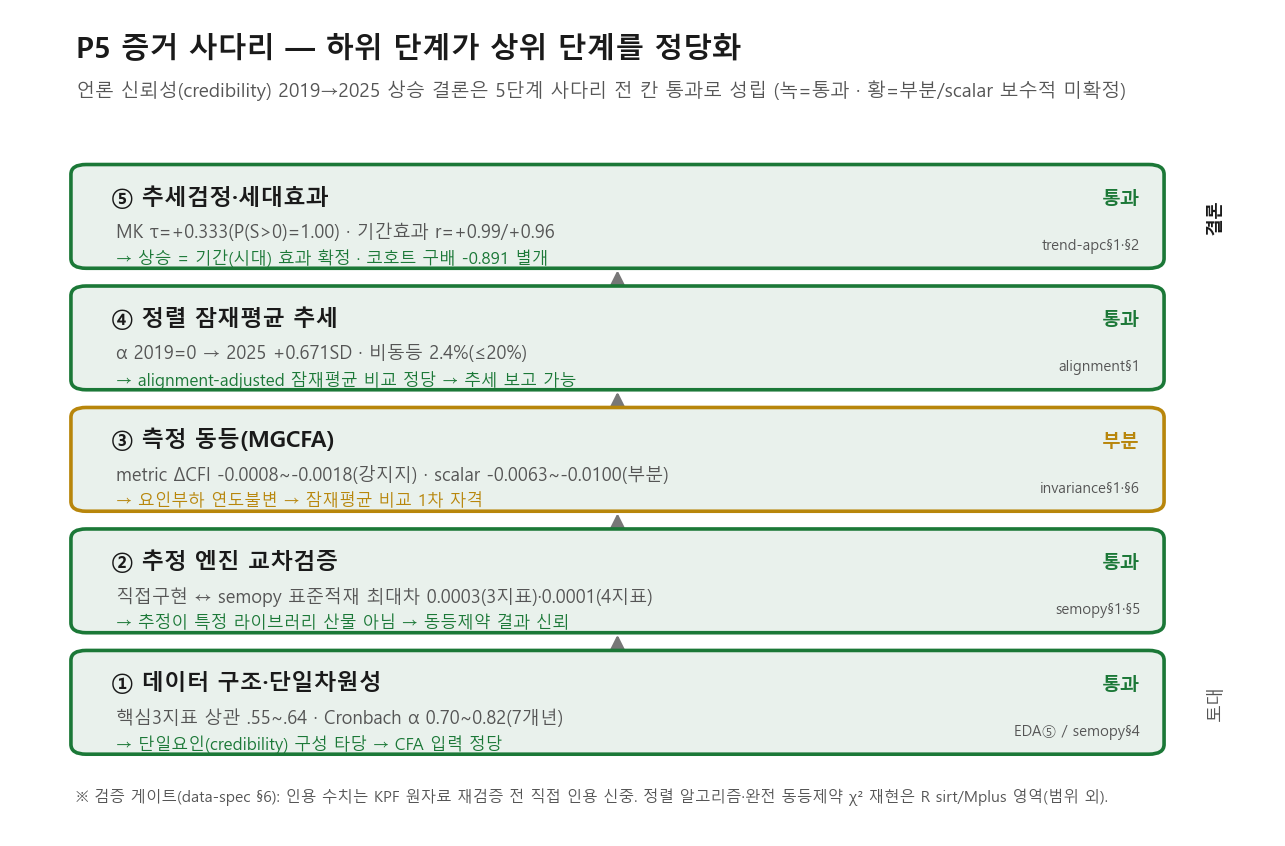

In [3]:
p1 = P.panel_evidence_ladder()
print(f"저장: {p1.relative_to(P.ROOT)}")
display(Image(filename=str(p1), width=940))

**관찰**: ①→⑤ 전 칸이 '통과'(③만 부분 — 위 [시각화] 해설대로 설계적 우회로 흡수). 사다리 구조의 힘은 **반박 지점의 특정 가능성**이다: 이 결론에 이의를 제기하려면 "추세가 이상하다"가 아니라 "몇 번째 칸의 어느 수치가 틀렸다"고 말해야 하며, 각 칸은 출처 문서·재현 스크립트(§7 재현 경로)로 되짚을 수 있다.

**증거 사다리 — 완료**

## **3. [발견] 삼각검증 — 종점 방향·2025 반등은 일치, 단년 저점은 정직하게 어긋난다**

삼각검증(triangulation)의 논리: 한 지표의 추세는 그 지표의 결함(측정·집계·모형 선택)을 그대로 공유한다. 그러나 **구성개념·척도·추정방법이 서로 다른 궤적들**은 오차 구조가 독립에 가깝다 — 그런 궤적들이 같은 이야기를 하면, 그 이야기가 특정 방법 선택의 인공물일 가능성은 급감한다.

| 궤적 | 구성개념 | 척도 | 추정 |
|------|---------|------|------|
| **A. 정렬 잠재평균 α** | credibility(공정·전문·정확) 잠재요인 | 2019-SD 단위 | 정렬법 MLE(23) |
| **B. 단일문항** `trust_news_overall` | 뉴스 **전반** 신뢰(별개 구성개념) | 1~5 manifest | 가중평균(wt_year_eq) |
| **C. 합성** `cred_mean` | credibility 3지표 단순평균 | 1~5 manifest | 가중평균(wt_year_eq) |
| + **APC 기간효과**(HAPC·IE) | C를 연령·기간·코호트로 분해한 기간 성분 | 편차 | GLMM/최소노름(24) |

A↔C는 구성개념이 같고 추정이 다르며(잠재 vs manifest), A↔B는 구성개념부터 다르다. 아래 코드 셀은 인용 상수로 네 궤적을 한 표에 모으고, 종점 방향·저점 시점·연차패턴 상관을 **직접 계산**한다(문서 §3의 수치가 상수로부터 재도출되는지 확인 겸).

In [4]:
tri = pd.DataFrame(index=P.YEARS)
tri.index.name = "연도"
tri["A. 정렬 α(2019-SD)"] = [P.ALIGN_ALPHA[y] for y in P.YEARS]
tri["B. 단일문항(1~5)"] = [P.TRUST_SINGLE.get(y, np.nan) for y in P.YEARS]
tri["C. 합성 cred_mean(1~5)"] = [P.CRED_MEAN[y] for y in P.YEARS]
tri["기간효과 HAPC"] = [P.PERIOD_HAPC[y] for y in P.YEARS]
tri["기간효과 IE"] = [P.PERIOD_IE[y] for y in P.YEARS]
display(tri)

# 종점 방향(각 궤적의 가용 시작연도 → 2025)
endA = P.ALIGN_ALPHA[2025] - P.ALIGN_ALPHA[2019]
endB = P.TRUST_SINGLE[2025] - P.TRUST_SINGLE[2020]
endC = P.CRED_MEAN[2025] - P.CRED_MEAN[2019]
print(f"종점 방향: A {endA:+.3f} · B {endB:+.3f} · C {endC:+.3f}  →  3/3 양(+)")

# 단년 저점(기준연도 이후) — A와 B의 저점 '시점'이 어긋난다
lowA = min((y for y in P.YEARS if y >= 2020), key=lambda y: P.ALIGN_ALPHA[y])
lowB = min(P.TRUST_SINGLE, key=P.TRUST_SINGLE.get)
lowC = min((y for y in P.YEARS if y >= 2020), key=lambda y: P.CRED_MEAN[y])
print(f"단년 저점: A={lowA} · B={lowB} · C={lowC}  →  A·C는 2024로 일치, B만 2022")

# 연차패턴 일치도(A↔B, 겹치는 2020~2025) + APC 기간효과 동행
from scipy.stats import spearmanr
y6 = sorted(P.TRUST_SINGLE)
rho_ab = spearmanr([P.ALIGN_ALPHA[y] for y in y6], [P.TRUST_SINGLE[y] for y in y6])[0]
a = np.array([P.ALIGN_ALPHA[y] for y in P.YEARS])
r_hapc = np.corrcoef(a, [P.PERIOD_HAPC[y] for y in P.YEARS])[0, 1]
r_ie = np.corrcoef(a, [P.PERIOD_IE[y] for y in P.YEARS])[0, 1]
r_hi = np.corrcoef([P.PERIOD_HAPC[y] for y in P.YEARS], [P.PERIOD_IE[y] for y in P.YEARS])[0, 1]
print(f"A↔B 연차패턴 Spearman = {rho_ab:+.3f} (중간 — 단년 등락은 어긋남)")
print(f"APC 동행: 정렬↔HAPC r={r_hapc:+.3f} · 정렬↔IE r={r_ie:+.3f} · HAPC↔IE r={r_hi:+.3f}")

,A. 정렬 α(2019-SD),B. 단일문항(1~5),C. 합성 cred_mean(1~5),기간효과 HAPC,기간효과 IE
연도,,,,,
2019,0.000,NaN,3.034,-0.206,-0.194
2020,0.354,3.297,3.249,0.003,0.026
2021,0.474,3.322,3.305,0.067,0.079
2022,0.453,3.151,3.211,0.014,-0.008
2023,0.394,3.272,3.190,-0.001,-0.027
2024,0.298,3.360,3.176,-0.053,-0.047
2025,0.671,3.436,3.390,0.176,0.171


종점 방향: A +0.671 · B +0.139 · C +0.356  →  3/3 양(+)
단년 저점: A=2024 · B=2022 · C=2024  →  A·C는 2024로 일치, B만 2022


A↔B 연차패턴 Spearman = +0.200 (중간 — 단년 등락은 어긋남)
APC 동행: 정렬↔HAPC r=+0.990 · 정렬↔IE r=+0.959 · HAPC↔IE r=+0.987


**관찰 — 일치하는 것(§3.1)**:

1. **종점 방향 3/3 양(+)** — A +0.671 / B +0.139 / C +0.356, 그리고 **2025가 세 궤적 모두 가용구간 최고치**.
2. **2025 반등 변곡점 일치** — A(2024 저점 +0.298 → +0.671 단년 최대폭 반등)와 C(2024 저점 3.176 → 3.390)가 같은 자리에서 꺾인다.
3. **MK 부호 일치** — τ = A +0.333 · B +0.467 · C +0.143, 모두 양(24 §4).
4. **잠재 분해 수준의 재현** — APC 기간효과(HAPC·IE)가 정렬추세와 r=+0.990/+0.960(상호 +0.988): manifest 궤적의 일치가 연령·코호트를 걷어낸 뒤에도 남는다.

**관찰 — 어긋나는 것(§3.2, 정직한 불일치)**:

- 단년 저점 시점이 **A=2024 vs B=2022**로 다르고, A↔B 연차패턴 Spearman은 +0.200(중간)에 그친다.
- 해석: B는 2022 표본 12배 확대·구성 변화의 직격을 받았고, 애초에 A·C와 **구성개념(뉴스 전반 신뢰 vs 공정·전문·정확 credibility)·척도가 다르다**. 따라서 합의의 범위를 "수준·단년 시점"이 아니라 **"종점 방향과 2025 반등"** 으로 한정한다 — 이 한정이 삼각검증 결론의 정확한 적용 범위다.

### **Decision Box ② — 불일치의 처리: 왜 숨기거나 뭉개지 않는가**

**기준: 세 궤적의 단년 등락이 어긋날 때, 보고 전략을 어디에 두는가.**

| 대안 | 처리 | 기각/채택 사유 |
|------|------|------|
| (a) 일치 지표만 제시 | B(단일문항)를 표에서 생략 | ❌ **체리피킹** — 삼각검증의 전제(서로 독립인 잣대)를 스스로 파괴. 심사자가 원자료에서 B를 재확인하는 순간 일치 주장 전체의 신뢰가 무너진다 |
| (b) 세 궤적을 평균해 "합의 곡선" 제시 | 하나의 매끈한 곡선 | ❌ 척도(SD vs 1~5)·구성개념이 달라 평균은 수학적으로 무의미 + 불일치 정보를 **은폐**하는 효과 |
| (c) **일치/불일치 분리 보고** | 일치=종점 방향·반등(결론 승격) / 불일치=단년 저점 시점(§5 한계 명시) | ✅ **채택** — 불일치는 결론을 약화하는 게 아니라 **결론의 적용 범위를 정확히 긋는다**: "단년 수준 비교는 하지 않는다"는 해석 규율의 근거가 된다 |

**왜 이 선이 중요한가**: 정직한 불일치의 보고가 오히려 일치의 증거가치를 올린다 — **불일치를 보고할 의지가 있는 파이프라인이 보고한 일치**이기 때문이다. 반대로 (a)·(b)를 택한 보고서에서 일치는 선별의 산물인지 구분할 수 없다.

**[시각화] 삼각검증 패널 2연** — **좌**: 세 궤적을 각자 z-표준화해 겹친다. z-표준화는 각 궤적 내부의 상대 위치만 남기고 척도 차를 제거하는 장치다 — 곧 이 그림에서 읽어야 하는 것은 수준(어느 선이 높은가)이 아니라 **형상**(어디서 꺾이고 종점이 어디를 향하는가)이다. 2024→2025 음영이 반등 구간. **우**: 정렬추세(α)와 APC 기간효과 2종(HAPC·IE)의 동행 — 이 겹침이 "상승=기간(시대) 효과"(24)의 시각적 형태다.

저장: docs\design\figures\p5_triangulation.png
[자기점검 PASS] 종점 방향 부호 일치: A=+0.671 · B=+0.139 · C=+0.356


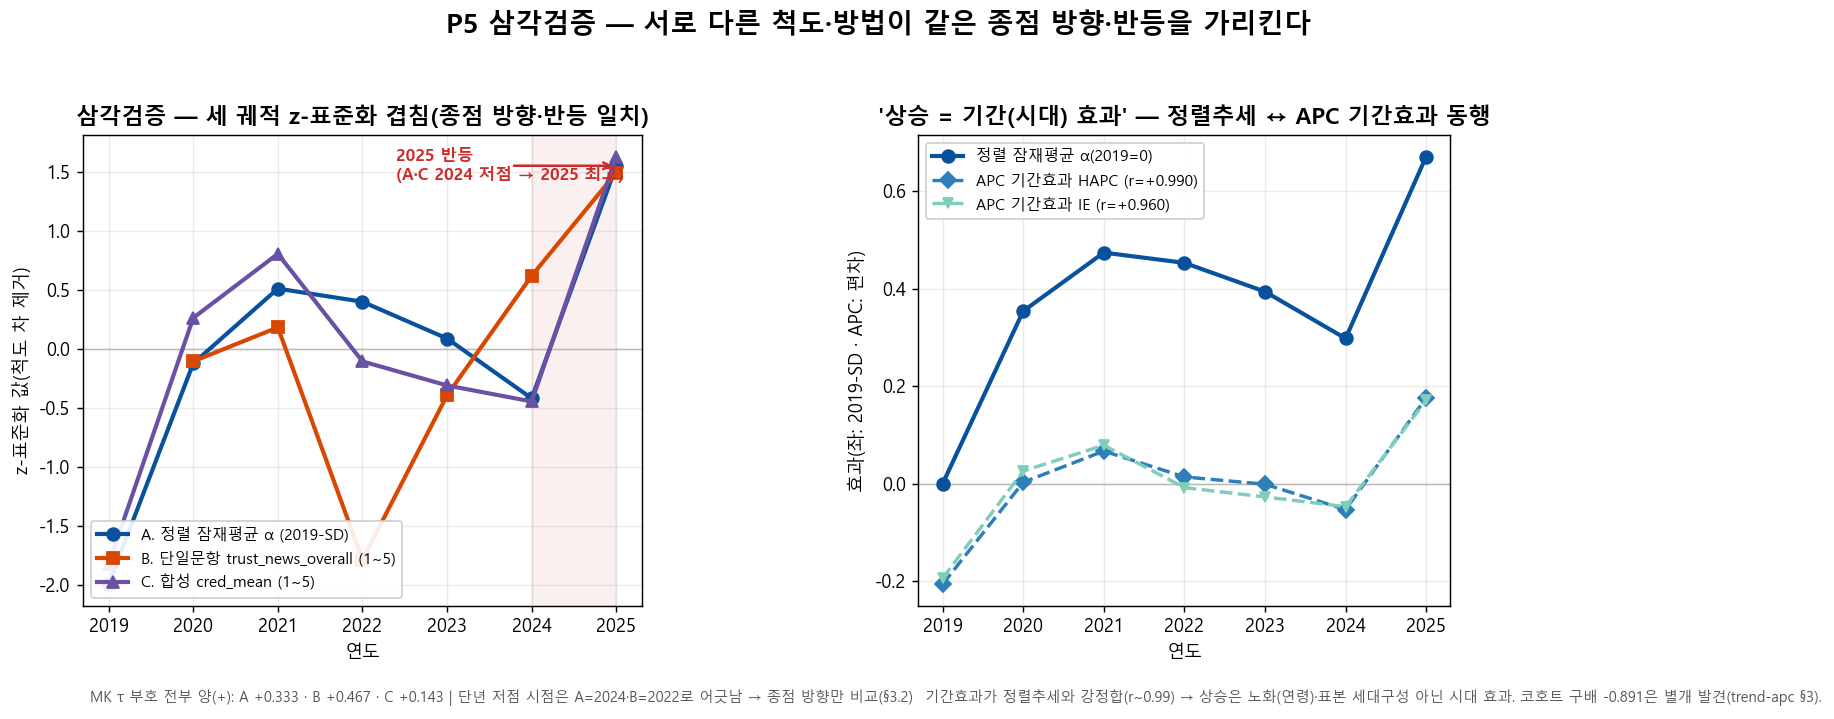

In [5]:
p2 = P.panel_triangulation()
print(f"저장: {p2.relative_to(P.ROOT)}")

# 모듈 main()과 동일한 자기점검 — 종점 방향 부호 일치(삼각검증의 핵심 불변식)
assert endA > 0 and endB > 0 and endC > 0, "종점 방향 부호 불일치 — 인용 상수 점검"
print(f"[자기점검 PASS] 종점 방향 부호 일치: A={endA:+.3f} · B={endB:+.3f} · C={endC:+.3f}")
display(Image(filename=str(p2), width=980))

**관찰**: 좌측 z-겹침에서 세 궤적은 중간연도(2021~2024)에 서로 흩어졌다가 **2025 종점에서 한 방향으로 모인다** — "수준의 완전 일치"가 아니라 "독립적인 세 잣대가 같은 종점 방향과 반등을 가리킨다"가 삼각검증의 결론임을 그림 자체가 보여준다. 우측에서 기간효과 2종이 정렬추세와 거의 포개지는 것(r 0.96~0.99)은, 이 상승이 노화(연령효과 범위 0.111)나 표본 세대구성 변화(코호트는 별개 구배)로 설명되지 않는 **시대 효과**라는 24의 결론을 종합 수준에서 재확인한다.

**삼각검증 — 완료**

## **4. 강건성 종합 — 여섯 축으로 흔들어도 같은 방향**

P2~P4 각 단계에 흩어져 있던 robustness 점검을 한 표에 모은다. **모든 변형이 같은 방향(상승)·비단조 패턴을 재현**한다.

| 흔드는 축 | 변형 | 결과(인용) | 결론 영향 | 출처 |
|-----------|------|-----------|:---:|------|
| **정렬 가중치** | 연도균등(주) vs A&M √NₘNₕ vs 설계가중적률 | Δα(2019→2025) = **+0.671 / +0.673 / +0.610**, 전부 비단조 | 방향 불변 | alignment §1·§2 |
| **비동등 비율** | 가중 변형별 | 2.4% / 2.4% / 14.3% — 전부 ≤20% | 비교 정당 유지 | alignment §1·§2 |
| **2022 표본상한** | 6,000 하향표집(MGCFA) | metric/scalar ΔCFI 결론 동일 | 결론 불변 | invariance §2 |
| **지표 수** | 3지표(2019~2025) vs 4지표(2019~2022) | 4지표도 정렬 Δα=+0.435 단조증가·metric 동등 | 방향 일치 | invariance §3 / alignment §3 |
| **집계 방법** | 잠재(정렬) vs manifest 합성(cred_mean) | 둘 다 2024 저점·2025 반등 | 변곡점 일치 | EDA ③·⑥ |
| **추세 불확실성** | 정렬 부트스트랩 B=150에 MK 전파 | τ 평균 +0.415(95% [+0.333, +0.524]), **P(S>0)=1.00** | 증가 확률 100% | trend-apc §1 |

### **4.1 주의해서 읽어야 할 민감점 — 결론을 약화하진 않으나 강조 금지**

1. **2019→2020 계단(+0.354)**: 정렬 추세 상승폭의 큰 부분이 기준연도 직후 단일 계단에서 발생. 2019는 신뢰 단일문항이 구조적으로 부재했던 연도 → 원자료 재검증(노트북 `12`)에서 **공식 통계 실재로 확인**(배터리 5문항 전부 상승·가설 5종 배제), 원인 귀속만 분해 불가(원인 각주 의무, p6-pdf-structure §4-a).
2. **2022 표본지배(N=58,936, 64.8%)**: 비가중 통합 시 2022가 추세를 지배 → 모든 추세·평균은 `wt_year_eq`로 산출, MGCFA는 하향표집 민감도로 교차확인(EDA ①, invariance §2).
3. **3지표 ΔRMSEA 인위적 팽창**: 3지표 단일요인은 configural이 포화(RMSEA=0)라 metric 단계 ΔRMSEA가 0에서 출발해 부풀려짐 → **ΔCFI 우선** 해석, 4지표 비포화 모형이 보강(invariance §6).
4. **대집단 과검정력**: N=90,996에서 Δχ²는 사소한 오차도 유의로 만듦 → **ΔCFI/ΔRMSEA(효과크기)** 기반 판정(invariance §6).

## **5. 한계·검증 게이트 — 무엇을 아직 단정하지 않는가**

**5.1 검증 게이트(`data-spec.md` §6 → 해소, 2026-07-11) — 인용 규율**: 본 파이프라인 수치는 하모나이즈 산출이며, KPF 원자료(보고서 통계표) 재검증에서 신뢰 절대수준·배터리·`cred_mean`이 **전 셀 일치**했다([kpf-revalidation](../docs/design/kpf-revalidation.md) · 입증 노트북 `12`). 재검증 1순위였던 ① 2019→2020 계단은 **공식 통계 실재**(원인 각주 의무), ② 신뢰 절대수준은 **확정 인용 가능**으로 판정 — 이후 인용 규율은 p6-pdf-structure §3 자격등급 표가 SSOT다(잔여 게이트: 매체별 이용률 정의 대조·뉴스회피 출처 → 해당 수치 미인용 방침).

**5.2 방법론적 한계(정직)**: ① 정렬 알고리즘·완전 동등제약 χ² 재현의 외부 교차검증 부재(R `sirt`/Mplus 범위 외 — §2 사다리 한계) ② 완전 scalar 미확정(그래서 정렬법) ③ MK 저검정력(n=7, 점추정 p=0.381 — 무게는 부호·P(S>0)=1.00에) ④ APC 완전식별 불가(간격차 부분완화·HAPC↔IE 상호 +0.988로 보강, 산출변수는 manifest 합성) ⑤ 삼각검증 단년 저점 불일치(§3.2 — "단년 수준 비교 안 함" 규율의 근거).

### **Decision Box ③ — 결론 자격등급: 어디까지 말하고 어디서 멈추는가**

**기준: 사다리를 전부 통과한 뒤에도, 주장마다 다른 등급의 자격을 부여한다.**

| 등급 | 주장 | 조건·근거 |
|------|------|------|
| ✅ **검증된 결과**(인용 가능) | "credibility 잠재요인은 2019→2025 **상승 방향**·2025 반등, 이는 **기간(시대) 효과**" | 4관문(C1~C4) 통과 + 원자료 재검증 통과(노트북 `12`) |
| ⚠️ **방향만**(수량 강조 금지) | 절대 변화량(+0.671 SD)·2019→2020 계단 크기 | 모형 의존 SD 단위(재검증 대상 아님) — 축·부록에만(p6 §3.5). 원척도 신뢰 절대수준은 재검증 통과로 ✅ 확정 인용 승격 |
| 🔹 **독립 발견**(추세와 별개) | **코호트 구배 -0.891**(젊은 세대일수록 낮음) → 세대교체 시 총평균 하방 압력 | trend-apc §3 — 기간효과와 독립 성분 |
| ❌ **금지** | "**유의한** 단조 증가 추세"(점추정 p=0.381) · 잔여 게이트 미해소 수치(매체별 이용률 추이·뉴스회피 72%) · 단년 수준 비교 | 24 DB③ · p6-pdf-structure §3.6 |

**왜 등급인가**: "검증됐다/안 됐다"의 이분법은 +0.671이라는 숫자와 "상승 방향"이라는 판단을 같은 등급으로 취급하게 만든다. 실제로는 **방향(4중 수렴)이 크기(모형 의존)보다 훨씬 단단하다** — 등급 분리가 이 비대칭을 보고 언어에 새긴다.

## **6. 검증 셀 — 인용 상수 ↔ SSOT 문서 수치, drift 없음 (입증)**

21~24의 검증 셀이 "재계산 결과가 문서 수치를 재현하는가"를 물었다면, 30의 src는 **재계산하지 않으므로** 위험의 종류가 다르다: 계산 오류가 아니라 **전사(轉寫) 오류** — 모듈에 하드코딩된 인용 상수가 출처 문서와 어긋나는 **drift**다(문서가 갱신됐는데 상수가 낡거나, 옮겨 적다 한 자리가 틀리는 경우).

그래서 이 셀은 출처 문서 4종의 **마크다운 표·문장을 정규식으로 직접 파싱**해 모듈 상수 5종의 전 원소(총 34개 수치)와 일치함을 assert하고, 사다리(LADDER)가 인용하는 핵심 수치 문자열의 존재, 그리고 상수로부터 **재도출한 상관**(APC 동행 r·Spearman)까지 문서 보고치와 대조한다. 이것이 이 노트북의 핵심 검증 포인트다.

In [6]:
def read(name):
    return (DOCS / name).read_text(encoding="utf-8")

align_doc, apc_doc = read("alignment-trust-trend.md"), read("trend-apc-results.md")
eda_doc, p5_doc = read("eda-overview.md"), read("p5-evaluation.md")

def table_rows(text, start, end):
    """start~end 구간의 마크다운 표에서 '| 연도 | ...' 행을 {연도: [셀,...]}로 파싱."""
    seg = text.split(start, 1)[1]
    if end:
        seg = seg.split(end, 1)[0]
    rows = {}
    for m in re.finditer(r"^\|\s*(20\d\d)\s*\|(.+)$", seg, re.M):
        rows[int(m.group(1))] = [c.strip().replace(",", "")
                                 for c in m.group(2).strip().strip("|").split("|")]
    return rows

# (a) 정렬 α — alignment §1 주모형 표 ↔ P.ALIGN_ALPHA (7개년 전 원소)
doc_alpha = {y: float(c[0]) for y, c in table_rows(align_doc, "## 1.", "## 2.").items()}
assert doc_alpha == P.ALIGN_ALPHA, (doc_alpha, P.ALIGN_ALPHA)

# (b) 단일문항 — alignment §4 표 ↔ P.TRUST_SINGLE (6개년)
doc_single = {y: float(c[0]) for y, c in table_rows(align_doc, "## 4.", "## 5.").items()}
assert doc_single == P.TRUST_SINGLE, (doc_single, P.TRUST_SINGLE)

# (c) 기간효과 — trend-apc §1 표(α·HAPC·IE 3열) ↔ P.PERIOD_HAPC / P.PERIOD_IE (+ α 재대조)
rt = table_rows(apc_doc, "## 1.", "### 1.1")
assert {y: float(c[0]) for y, c in rt.items()} == P.ALIGN_ALPHA
assert {y: float(c[1]) for y, c in rt.items()} == P.PERIOD_HAPC
assert {y: float(c[2]) for y, c in rt.items()} == P.PERIOD_IE

# (d) 합성 cred_mean — eda-overview ③ 문장 ↔ P.CRED_MEAN (7개년)
line = re.search(r"`cred_mean`\(3지표\) 연도 가중평균: ([^\n]+)", eda_doc).group(1)
assert [float(v) for v in re.findall(r"\d\.\d{3}", line)] == [P.CRED_MEAN[y] for y in P.YEARS]
print("[PASS] 인용 상수 5종 × 전 원소(34개 수치) = 출처 문서 표·문장과 일치 (drift 없음)")

# (e) 사다리(LADDER)·§5가 인용하는 핵심 수치 문자열 — 출처 문서에 실재하는가
for needle, doc, label in [
    ("비동등 비율**: **2.4%", align_doc, "④ 비동등 2.4%"),
    ("Δα=+0.671", align_doc, "④ Δα=+0.671"),
    ("최대 절대차 0.0003", read("mgcfa-semopy-crossval.md"), "② semopy 최대차 0.0003"),
    ("-0.0008", read("mgcfa-invariance-results.md"), "③ metric ΔCFI -0.0008"),
    ("τ=+0.333", apc_doc, "⑤ MK τ=+0.333"),
    ("P(S>0)=1.000", apc_doc, "⑤ P(S>0)=1.00"),
    ("**+0.990**", apc_doc, "⑤ HAPC r=+0.990"),
    ("**+0.960**", apc_doc, "⑤ IE r=+0.960"),
    ("**-0.891**", apc_doc, "코호트 구배 -0.891"),
    ("+0.671", p5_doc, "종합문서 헤드라인 수치"),
    ("2.4%", p5_doc, "종합문서 비동등"),
]:
    assert needle in doc, f"인용 문자열 미발견: {label}"
print("[PASS] 사다리·자격등급이 인용하는 핵심 수치 11건 — 출처 문서에 실재")

# (f) 상수로부터 재도출한 상관 = 문서 보고치 (§3 계산 셀의 값 재사용)
assert np.isclose(r_hapc, 0.990, atol=5e-3), r_hapc
assert np.isclose(r_ie, 0.960, atol=5e-3), r_ie
assert np.isclose(r_hi, 0.988, atol=5e-3), r_hi
assert np.isclose(rho_ab, 0.200, atol=1e-3), rho_ab
print("[PASS] 재도출 상관 = 문서 보고치: HAPC +0.990 · IE +0.960 · 상호 +0.988 · Spearman +0.200")

# (g) 종합 figure 2종 산출 확인
for f in ["p5_evidence_ladder.png", "p5_triangulation.png"]:
    assert (DOCS / "figures" / f).stat().st_size > 20_000, f
print("[PASS] 종합 figure 2종 생성 확인 (docs/design/figures/)")

print("\n[검증 PASS] 30은 새 수치를 만들지 않았고, 옮겨 적은 수치는 한 자리도 어긋나지 않았다")

[PASS] 인용 상수 5종 × 전 원소(34개 수치) = 출처 문서 표·문장과 일치 (drift 없음)
[PASS] 사다리·자격등급이 인용하는 핵심 수치 11건 — 출처 문서에 실재
[PASS] 재도출 상관 = 문서 보고치: HAPC +0.990 · IE +0.960 · 상호 +0.988 · Spearman +0.200
[PASS] 종합 figure 2종 생성 확인 (docs/design/figures/)

[검증 PASS] 30은 새 수치를 만들지 않았고, 옮겨 적은 수치는 한 자리도 어긋나지 않았다


**관찰**: (a)~(d)에서 상수 5종의 전 원소가 출처 문서의 표·문장과 **정확히 일치**(α 7 + 단일문항 6 + HAPC 7 + IE 7 + 합성 7 = 34개 수치, 근사 아닌 등호) — trend-apc §1 표의 α 열이 alignment §1과도 일치해 **문서 간 정합**까지 확인됐다. (e)에서 사다리·자격등급이 인용하는 핵심 수치 11건이 전부 출처에 실재하고, (f)에서 상수만으로 재도출한 상관이 문서 보고치(+0.990/+0.960/+0.988/+0.200)를 재현한다. 즉 이 노트북과 src가 말하는 모든 숫자는 **P2~P4 산출물로 소급 가능**하다.

**검증 — 완료**

## **7. 종합 — B트랙(종단) 파이프라인이 완결됐다**

### **7-1. 연구 질문 답**

- **Q1(승격 기준)**: 4관문 직렬 — C1 측정 동등(metric 강지지 + 비동등 2.4%) · C2 재현성(semopy 최대차 0.0003) · C3 삼각 일관성(종점 방향 3/3 + APC r≥+0.96) · C4 강건성(6축 변형 전부 동방향). **전부 통과** — "상승 방향·2025 반등·기간 효과"는 검증된 결과로 승격.
- **Q2(일치와 불일치)**: 일치 = 종점 방향·2025 반등·MK 부호·APC 동행. 불일치 = 단년 저점 시점(A 2024 vs B 2022, Spearman +0.200) — 숨기지 않고 분리 보고(DB②), "단년 수준 비교 안 함" 규율의 근거로 전환.
- **Q3(단정하지 않는 것)**: 크기(+0.671 SD·계단 +0.354)는 **방향만** 등급(모형 의존 — 축·부록에만, p6 §3.5); 원척도 절대수준은 재검증 통과(노트북 `12`)로 ✅ 확정 인용. "유의한 추세" 표현 금지(점추정 p=0.381). 코호트 구배 -0.891은 추세와 **독립 발견**으로 별도 보고.

### **7-2. 단계별 요약**

| 단계 | 산출 | 판정 |
|------|------|:--:|
| §1 평가 기준 | 4관문(C1~C4) 정의·판정 | 전부 ✅ |
| §2 증거 사다리 | ①~⑤ 5칸(통과 4·부분 1) — 반박 지점 특정 가능 구조 | 성립 |
| §3 삼각검증 | 종점 방향 3/3·반등 일치·APC 동행 / 단년 저점 분리 보고 | 일치+정직한 불일치 |
| §4 강건성 | 6축 변형 전부 동방향 + 민감점 4건 명시 | 견고 |
| §5 게이트·등급 | 검증된 결과/방향만/독립 발견/금지 4등급 | 규율 확정 |
| §6 drift 검증 | 상수 34개·인용 11건·재도출 상관 4건 전부 일치 | PASS |

### **7-3. 횡단면 트랙과의 외적 타당도 (p5-evaluation.md §6)**

2025 횡단면(A트랙)에서 관찰된 **연령 정구배**(60+ 신뢰 최고)·**학력 역구배**(중졸이하 3.30 > 대학원 2.98, EDA ⑤)는 종단의 **코호트 구배**(-0.891: 젊은 코호트일수록 낮음)와 부호가 일치한다 — `03-health-index`·`04-personas-kmeans`의 2025 지수·페르소나는 7개년 추세의 **단면 스냅샷**으로 위치지어지며, 종단↔횡단이 상호 외적 타당도를 형성한다.

### **7-4. 다음 단계**

- 이로써 종단 트랙(B) 노트북 **13개 전부 완료**(10·11·20·21·22·23·24·30 + A트랙 01~04 다개년). P4 체인(21→22→23→24)의 결론이 P5(30)에서 자격 판정까지 마쳤다.
- (진행 기록) ① 일관성 검토 1회 완료(2026-07-03) → ② KPF 원자료 재검증 완료(2026-07-11 · 노트북 `12`) → ③ P6 논문형 PDF 조판 완료(`31`·`32`, `dist/report.pdf` 11p) → 다음 = **웹데모(F9)·최종 패키징**(마감 7/23).

**재현 경로**: `python src/p5_evaluation.py`(인용 상수 기반, parquet 불요). 원수치 재생성은 `src/mgcfa_invariance.py`·`src/mgcfa_semopy_crossval.py`·`src/alignment.py`·`src/trend_apc.py`·`src/eda_overview.py`.

## **8. `src/p5_evaluation.py` 코드리뷰 결론**

**코드리뷰 — 통과(결함 없음)**:

- **인용 상수 설계**: 재계산 대신 출처 문서 수치를 상수로 박제(각 상수 옆 출처 주석) — P5의 위상(새 추정 없는 메타 종합)과 정합하고, parquet 의존을 제거해 재현 비용을 최소화한다. 이 설계의 유일한 위험(drift)은 §6 검증 셀이 문서 파싱 대조로 커버. ✔
- **데이터-렌더 분리**: `LADDER`(단계·수치·논리·출처·판정)와 사다리 렌더 코드가 분리 — 단계 추가·판정 변경이 상수 수정만으로 반영되고, 판정 색(녹=통과·황=부분)이 문서 §2 판정 열과 일치. ✔
- **`_zscore` 겹침의 정직성**: 척도가 다른 3궤적을 각자 가용연도만으로 표준화 — 수준 비교를 원천 차단하고 형상(방향·변곡)만 남긴다. sd=0 가드 포함. ✔
- **자기점검**: `main()`이 종점 방향 부호 일치(endA/B/C > 0)를 assert — 상수 오타에 대한 최소 안전망(§6이 전수 대조로 보강). ✔
- **경미(결함 아님)**: ① `matplotlib.use("Agg")` 고정은 스크립트 실행용 정책 — 노트북에서는 파일 저장 후 `Image` 임베드로 자연 우회(본 노트북 방식). ② 상수 dict 키(연도)가 `YEARS`와 별도 정의이나, §6 (a)~(c)의 전 원소 등호 대조가 키 불일치까지 즉시 검출하므로 이중화 위험 없음.